# Diffusion calibrated summary comparison — no-MMD-loss run 1

This is the multi-diagnostic version of `density_noMMDloss_calibrated_thresholds.ipynb`.

- Rows: Density, L2, Linf, and MMD diagnostics.
- Columns: assumed M0, M1, M2, and M3.
- Overlays: `S=D`, `S=2D`, and `S=4D`.
- Simulated figures retain the original circle/square misspecified versus well-specified classification.
- LOWESS is identical to the source figure: `frac=0.7` for simulated data, `frac=1.0` for empirical data; logML is fitted on symlog-transformed rho after a central-90% filter, while posterior MMD and PMP are fitted on raw rho.

All data loading, centered-rho construction, threshold matching, classification, LOWESS, and plotting are implemented in this notebook. No diffusion project `.py` module is imported or called.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.scale import SymmetricalLogTransform
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "benchmark" / "examples" / "diffusion").is_dir()
)
DIFFUSION_DIR = PROJECT_ROOT / "benchmark" / "examples" / "diffusion"
NPE_RESULT_DIR = DIFFUSION_DIR / "results" / "NPE_results"
POSTERIOR_DIR = DIFFUSION_DIR / "results" / "posterior_diagnostics"

RUN_LABEL = 'no-MMD-loss run 1'
RUN_SLUG = 'summary_noMMDloss_run1'
CACHE_SUFFIX = 'noMMD'
THRESHOLD_PATH = DIFFUSION_DIR / 'calibration_outputs' / "thresholds.csv"

SUMMARY_SPECS = {"S=D": "S1D", "S=2D": "S2D", "S=4D": "S4D"}
MODELS = ("m0", "m1", "m2", "m3")
DIAGNOSTICS = ("density", "l2", "linf", "mmd")
MODEL_TITLES = {
    "m0": "M0: common threshold",
    "m1": "M1: threshold by condition",
    "m2": "M2: threshold by accumulator",
    "m3": "M3: condition x accumulator",
}
DIAGNOSTIC_LABELS = {
    "density": "Density",
    "l2": r"$L_2$",
    "linf": r"$L_\infty$",
    "mmd": "MMD",
}
DIAGNOSTIC_XLABELS = {
    "density": "Diagnostic: density-based",
    "l2": r"Diagnostic: $L_2$-based",
    "linf": r"Diagnostic: $L_\infty$-based",
    "mmd": "Diagnostic: MMD-based",
}
SUMMARY_COLORS = {"S=D": "#0072B2", "S=2D": "#E69F00", "S=4D": "#CC79A7"}
MODEL_MATCH_STYLES = {
    False: {"marker": "o", "size": 30, "label": "misspecified datasets"},
    True: {"marker": "s", "size": 40, "label": "well-specified datasets"},
}
TYPICAL_SET_FILL = "#DCEEDC"
THRESHOLD_LINEWIDTH = 1.8
LOWESS_FRAC = {"simulated": 0.7, "empirical": 1.0}
LOGML_CENTRAL_INTERVAL = 0.90
RHO_SYMLOG_LINTHRESH = 1.0
NONNEGATIVE_Y_MARGIN = 0.05

SAVE_FIGURES = False
FIGURE_DIR = DIFFUSION_DIR / "results" / "plots" / f"{RUN_SLUG}_exact_density_style"

# These are the medians stored in the matching reference-suite caches. Keeping
# the small values here avoids importing BayesFlow or any diffusion project module.
REFERENCE_MEDIANS = {'S1D': {'m0': {'density': -0.5305512788295745,
                'l2': 0.8496658024007212,
                'linf': 0.7837747854237611,
                'mmd': 0.5954343430012691},
         'm1': {'density': -0.6459086542129517,
                'l2': 0.9045717035294814,
                'linf': 0.8241201747682023,
                'mmd': 0.6075763320111311},
         'm2': {'density': -0.7222129567861559,
                'l2': 0.8994597265262727,
                'linf': 0.8201699050160653,
                'mmd': 0.6078052061981976},
         'm3': {'density': -1.6189669394493098,
                'l2': 0.9421358688185928,
                'linf': 0.8448853217007282,
                'mmd': 0.6168366335025985}},
 'S2D': {'m0': {'density': -0.5752446014881132,
                'l2': 0.7489806607925247,
                'linf': 0.6742644489598492,
                'mmd': 0.6027175962724373},
         'm1': {'density': -0.6588786458969116,
                'l2': 0.8215518488353896,
                'linf': 0.7321014958448616,
                'mmd': 0.6131996049339673},
         'm2': {'density': -0.707884165763855,
                'l2': 0.8344783029116751,
                'linf': 0.7522844636022136,
                'mmd': 0.6251676965446681},
         'm3': {'density': -1.4136460795402528,
                'l2': 0.8434987304426449,
                'linf': 0.7528715011989057,
                'mmd': 0.6083644406567995}},
 'S4D': {'m0': {'density': -0.9862496747970582,
                'l2': 0.7065411757697488,
                'linf': 0.6359897310126077,
                'mmd': 0.6040012275953502},
         'm1': {'density': -1.409118712425233,
                'l2': 0.7564182547704118,
                'linf': 0.6702320840807646,
                'mmd': 0.6103500926180709},
         'm2': {'density': -1.1312242326736452,
                'l2': 0.7709866931182278,
                'linf': 0.6954086862991681,
                'mmd': 0.6093337170811025},
         'm3': {'density': -2.4131827049255357,
                'l2': 0.7847849256287552,
                'linf': 0.7053361122080273,
                'mmd': 0.6163430813884293}}}

print("Project root:", PROJECT_ROOT)
print("Thresholds:", THRESHOLD_PATH)


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/yimingzang/Documents/Project/benchmark2
Thresholds: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/calibration_outputs/thresholds.csv


In [2]:
def diagnostic_path(summary_token, diagnostic):
    return NPE_RESULT_DIR / (
        f"npe_{summary_token}_{CACHE_SUFFIX}_all_observed_diagnostic_{diagnostic}.csv"
    )


def posterior_path(summary_token):
    return POSTERIOR_DIR / (
        f"npe_{summary_token}_{CACHE_SUFFIX}_all_observed_posterior.csv"
    )


def load_calibration_thresholds():
    raw = pd.read_csv(THRESHOLD_PATH)
    required = {
        "generating_model", "npe_configuration", "metric",
        "lower_threshold", "threshold", "median",
    }
    missing = sorted(required.difference(raw.columns))
    if missing:
        raise ValueError(f"{THRESHOLD_PATH} is missing columns: {missing}")

    configuration_to_summary = {
        f"{token}_{CACHE_SUFFIX}": summary
        for summary, token in SUMMARY_SPECS.items()
    }
    raw = raw.loc[
        raw["npe_configuration"].isin(configuration_to_summary)
        & raw["generating_model"].isin(MODELS)
    ].copy()
    raw["summary"] = raw["npe_configuration"].map(configuration_to_summary)

    metric_columns = {
        "posterior_mmd": "posterior_mmd",
        "signed_logml_error": "log10_logml_error",
        "signed_pmp_error": "pmp_error",
    }
    rows = []
    for (model, summary), group in raw.groupby(
        ["generating_model", "summary"], sort=False
    ):
        row = {"model": model, "summary": summary}
        for metric, prefix in metric_columns.items():
            selected = group.loc[group["metric"].eq(metric)]
            if len(selected) != 1:
                raise ValueError(
                    f"Expected one {metric} threshold for {model}, {summary}; "
                    f"found {len(selected)}"
                )
            scale = np.log(10.0) if metric == "signed_logml_error" else 1.0
            row[f"{prefix}_lower_threshold"] = (
                float(selected["lower_threshold"].iloc[0]) / scale
            )
            row[f"{prefix}_upper_threshold"] = (
                float(selected["threshold"].iloc[0]) / scale
            )
            row[f"{prefix}_median"] = float(selected["median"].iloc[0]) / scale
        rows.append(row)

    thresholds = pd.DataFrame(rows)
    expected = len(MODELS) * len(SUMMARY_SPECS)
    if len(thresholds) != expected:
        raise ValueError(f"Expected {expected} threshold rows; found {len(thresholds)}")
    return thresholds


def load_comparison_data():
    frames = []
    required_by_model = (
        "d_{model}", "dm_low_{model}", "dm_high_{model}",
        "signed_logml_error_{model}", "signed_pmp_error_{model}",
        "gold_pmp_{model}", "regime_{model}",
    )

    for summary, summary_token in SUMMARY_SPECS.items():
        posterior_file = posterior_path(summary_token)
        if not posterior_file.exists():
            raise FileNotFoundError(posterior_file)
        posterior = pd.read_csv(posterior_file).loc[
            lambda frame: frame["model"].isin(MODELS),
            ["dataset", "id", "model", "observed_mmd"],
        ]

        for diagnostic in DIAGNOSTICS:
            result_file = diagnostic_path(summary_token, diagnostic)
            if not result_file.exists():
                raise FileNotFoundError(result_file)
            raw = pd.read_csv(result_file, keep_default_na=False)
            required = {"dataset", "id", "at_least_one_not_high_surprise"}
            for model in MODELS:
                required.update(name.format(model=model) for name in required_by_model)
            missing = sorted(required.difference(raw.columns))
            if missing:
                raise ValueError(f"{result_file} is missing columns: {missing}")

            all_high_surprise = raw[
                [f"regime_{model}" for model in MODELS]
            ].eq("high surprise").all(axis=1)
            model_frames = []
            for model in MODELS:
                median = REFERENCE_MEDIANS[summary_token][model][diagnostic]
                distance = pd.to_numeric(raw[f"d_{model}"], errors="coerce")
                low = pd.to_numeric(raw[f"dm_low_{model}"], errors="coerce")
                high = pd.to_numeric(raw[f"dm_high_{model}"], errors="coerce")
                scale = high - median
                if np.isclose(scale, 0.0).any():
                    raise ValueError(
                        f"{result_file}: upper threshold equals the reference median for {model}"
                    )
                model_frames.append(pd.DataFrame({
                    "dataset": raw["dataset"],
                    "id": raw["id"],
                    "diagnostic": diagnostic,
                    "summary": summary,
                    "model": model,
                    "rho": (distance - median) / scale,
                    "rho_low": (low - median) / scale,
                    "logml_error": (
                        pd.to_numeric(
                            raw[f"signed_logml_error_{model}"], errors="coerce"
                        ) / np.log(10.0)
                    ),
                    "pmp_error": pd.to_numeric(
                        raw[f"signed_pmp_error_{model}"], errors="coerce"
                    ),
                    "gold_pmp": pd.to_numeric(
                        raw[f"gold_pmp_{model}"], errors="coerce"
                    ),
                    "all_high_surprise": all_high_surprise,
                    "at_least_one_not_high_surprise": ~all_high_surprise,
                }))
            long = pd.concat(model_frames, ignore_index=True).merge(
                posterior,
                on=["dataset", "id", "model"],
                how="left",
                validate="one_to_one",
            )
            generating_model = long["dataset"].astype("string").str.extract(
                r"^simulated_from_(m[0-3])$", expand=False
            )
            long["model_matched"] = (
                generating_model.notna()
                & generating_model.eq(long["model"].astype("string"))
            )
            frames.append(long)

    data = pd.concat(frames, ignore_index=True).merge(
        load_calibration_thresholds(),
        on=["model", "summary"],
        how="left",
        validate="many_to_one",
    )
    data["diagnostic"] = pd.Categorical(
        data["diagnostic"], categories=DIAGNOSTICS, ordered=True
    )
    data["summary"] = pd.Categorical(
        data["summary"], categories=tuple(SUMMARY_SPECS), ordered=True
    )
    required_values = [
        "rho", "rho_low", "observed_mmd", "logml_error", "pmp_error",
        "posterior_mmd_lower_threshold", "posterior_mmd_upper_threshold",
        "log10_logml_error_lower_threshold", "log10_logml_error_upper_threshold",
        "pmp_error_lower_threshold", "pmp_error_upper_threshold",
    ]
    if data[required_values].isna().any().any():
        raise ValueError("Missing plotted values or calibrated thresholds")
    model_counts = data.groupby(
        ["diagnostic", "summary"], observed=True
    )["model"].nunique()
    if not model_counts.eq(len(MODELS)).all():
        raise ValueError("At least one diagnostic-summary group lacks all four models")
    return data.sort_values(
        ["diagnostic", "model", "summary", "dataset", "id"]
    ).reset_index(drop=True)


In [3]:
comparison_data = load_comparison_data()

completion_audit = (
    comparison_data.groupby(["diagnostic", "summary"], observed=True)
    .agg(
        rows=("id", "size"),
        datasets=("dataset", "nunique"),
        assumed_models=("model", "nunique"),
        well_specified=("model_matched", "sum"),
    )
    .reset_index()
)
print(f"Loaded {len(comparison_data):,} long-format rows for {RUN_LABEL}.")
print("All diagnostic-summary groups contain M0, M1, M2, and M3.")
completion_audit


Loaded 6,528 long-format rows for no-MMD-loss run 1.
All diagnostic-summary groups contain M0, M1, M2, and M3.


,diagnostic,summary,rows,datasets,assumed_models,well_specified
0,density,S=D,544,8,4,68
1,density,S=2D,544,8,4,68
2,density,S=4D,544,8,4,68
3,l2,S=D,544,8,4,68
4,l2,S=2D,544,8,4,68
5,l2,S=4D,544,8,4,68
6,linf,S=D,544,8,4,68
7,linf,S=2D,544,8,4,68
8,linf,S=4D,544,8,4,68
9,mmd,S=D,544,8,4,68


In [4]:
METRIC_SPECS = {
    "logml": {
        "column": "logml_error",
        "ylabel": (
            r"$\log_{10}\widehat{p}(y\mid M_j)-\log_{10}p(y\mid M_j)$"
            "\n(NPE, MCMC)"
        ),
        "threshold_columns": (
            "log10_logml_error_lower_threshold",
            "log10_logml_error_upper_threshold",
        ),
        "sharey": True,
        "yscale": "symlog",
        "y_linthresh": 1.0,
    },
    "posterior_mmd": {
        "column": "observed_mmd",
        "ylabel": "Posterior MMD\n(NPE, MCMC)",
        "threshold_columns": (
            "posterior_mmd_lower_threshold",
            "posterior_mmd_upper_threshold",
        ),
        "sharey": True,
        "yscale": "linear",
        "y_linthresh": 1.0,
    },
    "pmp": {
        "column": "pmp_error",
        "ylabel": r"$\widehat{p}(M_j\mid y)-p(M_j\mid y)$" "\n(NPE, MCMC)",
        "threshold_columns": (
            "pmp_error_lower_threshold",
            "pmp_error_upper_threshold",
        ),
        "sharey": False,
        "yscale": "linear",
        "y_linthresh": 0.1,
    },
}


def _compact_tick_label(value, _=None):
    if np.isclose(value, 0.0, atol=1e-12):
        return "0"
    return f"{value:.2g}"


def _limits(values, include=()):
    array = pd.to_numeric(values, errors="coerce").to_numpy(float)
    array = array[np.isfinite(array)]
    array = np.concatenate([array, np.asarray(include, dtype=float)])
    if not len(array):
        return -1.0, 1.0
    lower, upper = float(array.min()), float(array.max())
    span = max(upper - lower, np.finfo(float).eps)
    return lower - 0.07 * span, upper + 0.07 * span


def _central_interval(data, value_column, group_columns, coverage):
    tail = (1.0 - coverage) / 2.0
    grouped = data.groupby(group_columns, observed=True)[value_column]
    lower = grouped.transform(lambda values: values.quantile(tail))
    upper = grouped.transform(lambda values: values.quantile(1.0 - tail))
    return data.loc[data[value_column].between(lower, upper)].copy()


def _lowess_curve(x_values, y_values, frac, n_grid=180):
    x = pd.to_numeric(x_values, errors="coerce").to_numpy(float)
    y = pd.to_numeric(y_values, errors="coerce").to_numpy(float)
    keep = np.isfinite(x) & np.isfinite(y)
    x, y = x[keep], y[keep]
    order = np.argsort(x)
    x, y = x[order], y[order]
    if len(x) < 3:
        return x, y

    neighbors = min(len(x), max(3, int(np.ceil(frac * len(x)))))
    grid = np.linspace(x.min(), x.max(), n_grid)
    fitted = np.empty_like(grid)
    for index, center in enumerate(grid):
        distance = np.abs(x - center)
        bandwidth = np.partition(distance, neighbors - 1)[neighbors - 1]
        if bandwidth <= np.finfo(float).eps:
            fitted[index] = np.median(y[distance <= np.finfo(float).eps])
            continue
        weights = np.clip(1.0 - (distance / bandwidth) ** 3, 0.0, None) ** 3
        design = np.column_stack([np.ones_like(x), x - center])
        root_weight = np.sqrt(weights)
        fitted[index] = np.linalg.lstsq(
            design * root_weight[:, None], y * root_weight, rcond=None
        )[0][0]
    return grid, np.clip(fitted, y.min(), y.max())


def _symlog_lowess_curve(x_values, y_values, frac, n_grid=180):
    x = pd.to_numeric(x_values, errors="coerce").to_numpy(float)
    transform = SymmetricalLogTransform(base=10.0, linthresh=1.0, linscale=1.0)
    transformed_grid, fitted = _lowess_curve(
        pd.Series(transform.transform(x)), y_values, frac=frac, n_grid=n_grid
    )
    return transform.inverted().transform(transformed_grid), fitted


def _threshold_band(thresholds):
    values = np.asarray(tuple(thresholds), dtype=float)
    if not len(values):
        return None
    if len(values) == 1:
        return min(0.0, float(values[0])), max(0.0, float(values[0]))
    return float(values.min()), float(values.max())


def _shade_typical_set(ax, x_low, y_band=None, alpha=0.70):
    ax.axvspan(x_low, 1.0, color=TYPICAL_SET_FILL, alpha=alpha, zorder=0)
    if y_band is not None:
        ax.axhspan(*y_band, color=TYPICAL_SET_FILL, alpha=alpha, zorder=0)


def _scatter_model_matches(ax, data, x_column, y_column, color, alpha=0.50):
    matched = data["model_matched"].fillna(False).astype(bool)
    for is_matched, points in data.groupby(matched, sort=False):
        style = MODEL_MATCH_STYLES[bool(is_matched)]
        ax.scatter(
            points[x_column], points[y_column],
            s=style["size"] if is_matched else 20,
            marker=style["marker"], color=color, alpha=alpha,
            edgecolors="black" if is_matched else "none",
            linewidths=0.7 if is_matched else 0.0, zorder=2,
        )


def _summary_handles():
    return [
        Line2D(
            [0], [0], marker="o", color=SUMMARY_COLORS[summary],
            markerfacecolor=SUMMARY_COLORS[summary], markeredgecolor=SUMMARY_COLORS[summary],
            linewidth=2.0, markersize=6, label=summary,
        )
        for summary in SUMMARY_SPECS
    ]


def _model_match_handles(data):
    if not data["model_matched"].any():
        return []
    return [
        Line2D(
            [0], [0], marker=style["marker"], color="none",
            markerfacecolor="0.4",
            markeredgecolor="black" if is_matched else "none",
            markeredgewidth=0.8 if is_matched else 0.0,
            markersize=np.sqrt(style["size"]), label=style["label"],
        )
        for is_matched, style in MODEL_MATCH_STYLES.items()
    ]


def _nonnegative_plot_limits(upper):
    return -NONNEGATIVE_Y_MARGIN * float(upper), float(upper)


def _panel_thresholds(panel, threshold_columns):
    output = {}
    for summary in SUMMARY_SPECS:
        bounds = []
        for column in threshold_columns:
            values = pd.to_numeric(
                panel.loc[panel["summary"].eq(summary), column], errors="coerce"
            ).dropna().unique()
            if len(values) != 1:
                raise ValueError(
                    f"Expected one {column} for {summary}; found {len(values)}"
                )
            bounds.append(float(values[0]))
        output[summary] = tuple(bounds)
    return output


def plot_exact_density_style_grid(value, source_group):
    spec = METRIC_SPECS[value]
    y_column = spec["column"]
    threshold_columns = spec["threshold_columns"]
    frac = LOWESS_FRAC[source_group]

    reference_data = comparison_data.loc[
        comparison_data["dataset"].ne("empirical")
        if source_group == "simulated"
        else comparison_data["dataset"].eq("empirical")
    ].copy()
    plot_data = (
        _central_interval(
            reference_data, y_column,
            ["diagnostic", "model", "summary"],
            LOGML_CENTRAL_INTERVAL,
        )
        if value == "logml" else reference_data
    )

    fig, axes = plt.subplots(
        len(DIAGNOSTICS), len(MODELS),
        figsize=(16.0, 12.8), sharex=False, sharey=False, squeeze=False,
    )
    fig.subplots_adjust(
        left=0.075, right=0.94, bottom=0.10, top=0.93,
        wspace=0.22, hspace=0.42,
    )

    for row_index, diagnostic in enumerate(DIAGNOSTICS):
        reference_row = reference_data.loc[
            reference_data["diagnostic"].eq(diagnostic)
        ]
        plot_row = plot_data.loc[plot_data["diagnostic"].eq(diagnostic)]
        threshold_values = tuple(
            threshold
            for column in threshold_columns
            for threshold in pd.to_numeric(
                comparison_data.loc[
                    comparison_data["diagnostic"].eq(diagnostic), column
                ], errors="coerce"
            ).dropna().unique()
        )
        x_limits = _limits(
            pd.concat([reference_row["rho"], reference_row["rho_low"]]),
            include=(1.0,),
        )
        shared_y = (
            _limits(plot_row[y_column], include=threshold_values)
            if spec["sharey"] else None
        )
        if value == "posterior_mmd" and shared_y is not None:
            shared_y = _nonnegative_plot_limits(shared_y[1])

        for column_index, model in enumerate(MODELS):
            ax = axes[row_index, column_index]
            reference_panel = reference_row.loc[reference_row["model"].eq(model)]
            panel = plot_row.loc[plot_row["model"].eq(model)]
            rho_low = (
                reference_panel.groupby("summary", observed=True)["rho_low"]
                .median().reindex(tuple(SUMMARY_SPECS)).dropna()
            )
            panel_thresholds = _panel_thresholds(
                reference_panel, threshold_columns
            )
            active_thresholds = tuple(
                threshold
                for bounds in panel_thresholds.values()
                for threshold in bounds
            )
            for summary, bounds in panel_thresholds.items():
                plotted_bounds = bounds[1:] if value == "posterior_mmd" else bounds
                for threshold in plotted_bounds:
                    ax.axhline(
                        threshold, color=SUMMARY_COLORS[summary],
                        linestyle=":", linewidth=THRESHOLD_LINEWIDTH,
                        alpha=0.9, zorder=1,
                    )
            if not rho_low.empty:
                _shade_typical_set(
                    ax, float(rho_low.min()), _threshold_band(active_thresholds)
                )
            if value == "posterior_mmd":
                ax.axhline(0.0, color="0.55", linewidth=0.7, zorder=1)
            ax.axvline(1.0, color="0.2", linestyle="--", linewidth=1.0, zorder=1)

            for summary in SUMMARY_SPECS:
                overlay = panel.loc[panel["summary"].eq(summary)].dropna(
                    subset=["rho", y_column]
                )
                color = SUMMARY_COLORS[summary]
                _scatter_model_matches(ax, overlay, "rho", y_column, color)
                if value == "logml":
                    curve_x, curve_y = _symlog_lowess_curve(
                        overlay["rho"], overlay[y_column], frac=frac
                    )
                else:
                    curve_x, curve_y = _lowess_curve(
                        overlay["rho"], overlay[y_column], frac=frac
                    )
                ax.plot(curve_x, curve_y, color=color, linewidth=2.0, zorder=3)

            ax.set_xscale("symlog", base=10.0, linthresh=1.0, linscale=1.0)
            if spec["yscale"] == "symlog":
                ax.set_yscale(
                    "symlog", base=10.0,
                    linthresh=spec["y_linthresh"], linscale=1.0,
                )
                ax.yaxis.set_major_formatter(FuncFormatter(_compact_tick_label))
            ax.set_xlim(x_limits)
            if shared_y is not None:
                ax.set_ylim(shared_y)
                if column_index > 0:
                    ax.tick_params(labelleft=False)
            else:
                panel_limit_values = tuple(
                    threshold
                    for bounds in panel_thresholds.values()
                    for threshold in bounds
                )
                panel_y_limits = _limits(
                    panel[y_column], include=panel_limit_values
                )
                ax.set_ylim(panel_y_limits)

            ax.set_xlabel(DIAGNOSTIC_XLABELS[diagnostic], fontsize=10)
            ax.grid(color="0.90", linewidth=0.6, alpha=0.7)
            ax.spines[["top", "right"]].set_visible(False)
            ax.tick_params(labelsize=9)
            if row_index == 0:
                ax.set_title(MODEL_TITLES[model], fontsize=12)
            if column_index == len(MODELS) - 1:
                ax.annotate(
                    DIAGNOSTIC_LABELS[diagnostic],
                    xy=(1.035, 0.5), xycoords="axes fraction",
                    ha="left", va="center", rotation=-90, fontsize=12,
                    bbox={"facecolor": "#D9D9D9", "edgecolor": "0.45", "pad": 5},
                )

    fig.supylabel(
        spec["ylabel"], x=0.016, fontsize=11,
        ha="center", va="center", multialignment="center",
    )
    fig.suptitle(
        "Simulated datasets" if source_group == "simulated" else "Empirical dataset",
        y=0.985, fontsize=12,
    )
    handles = _summary_handles()
    handles.extend(_model_match_handles(plot_data))
    handles.append(Patch(
        facecolor=TYPICAL_SET_FILL, edgecolor="none", alpha=0.70,
        label="typical set",
    ))
    fig.legend(
        handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.015),
        ncol=len(handles), frameon=False, fontsize=9,
    )
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        stem = FIGURE_DIR / f"{source_group}_{value}_all_diagnostics_all_models"
        fig.savefig(stem.with_suffix(".png"), dpi=220)
        fig.savefig(stem.with_suffix(".pdf"))
    return fig, axes


## Simulated datasets

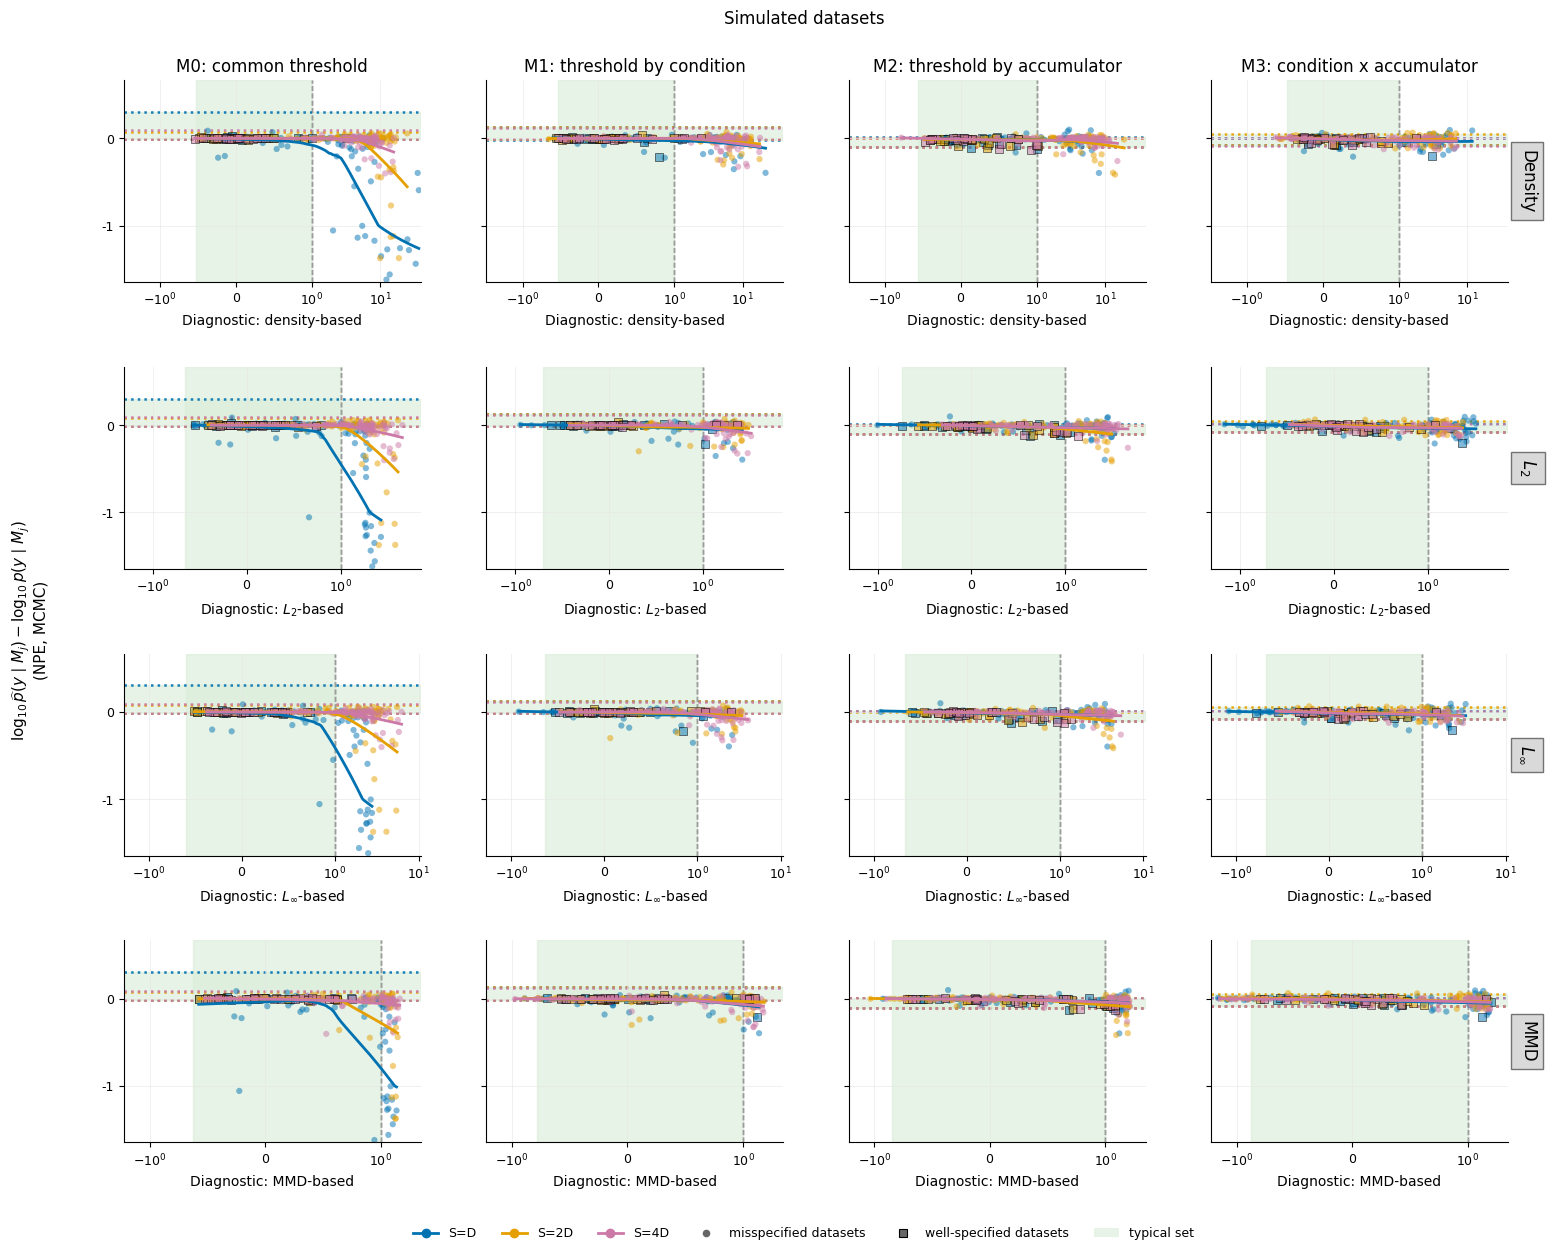

In [5]:
fig_sim_logml, _ = plot_exact_density_style_grid("logml", "simulated")
plt.show()

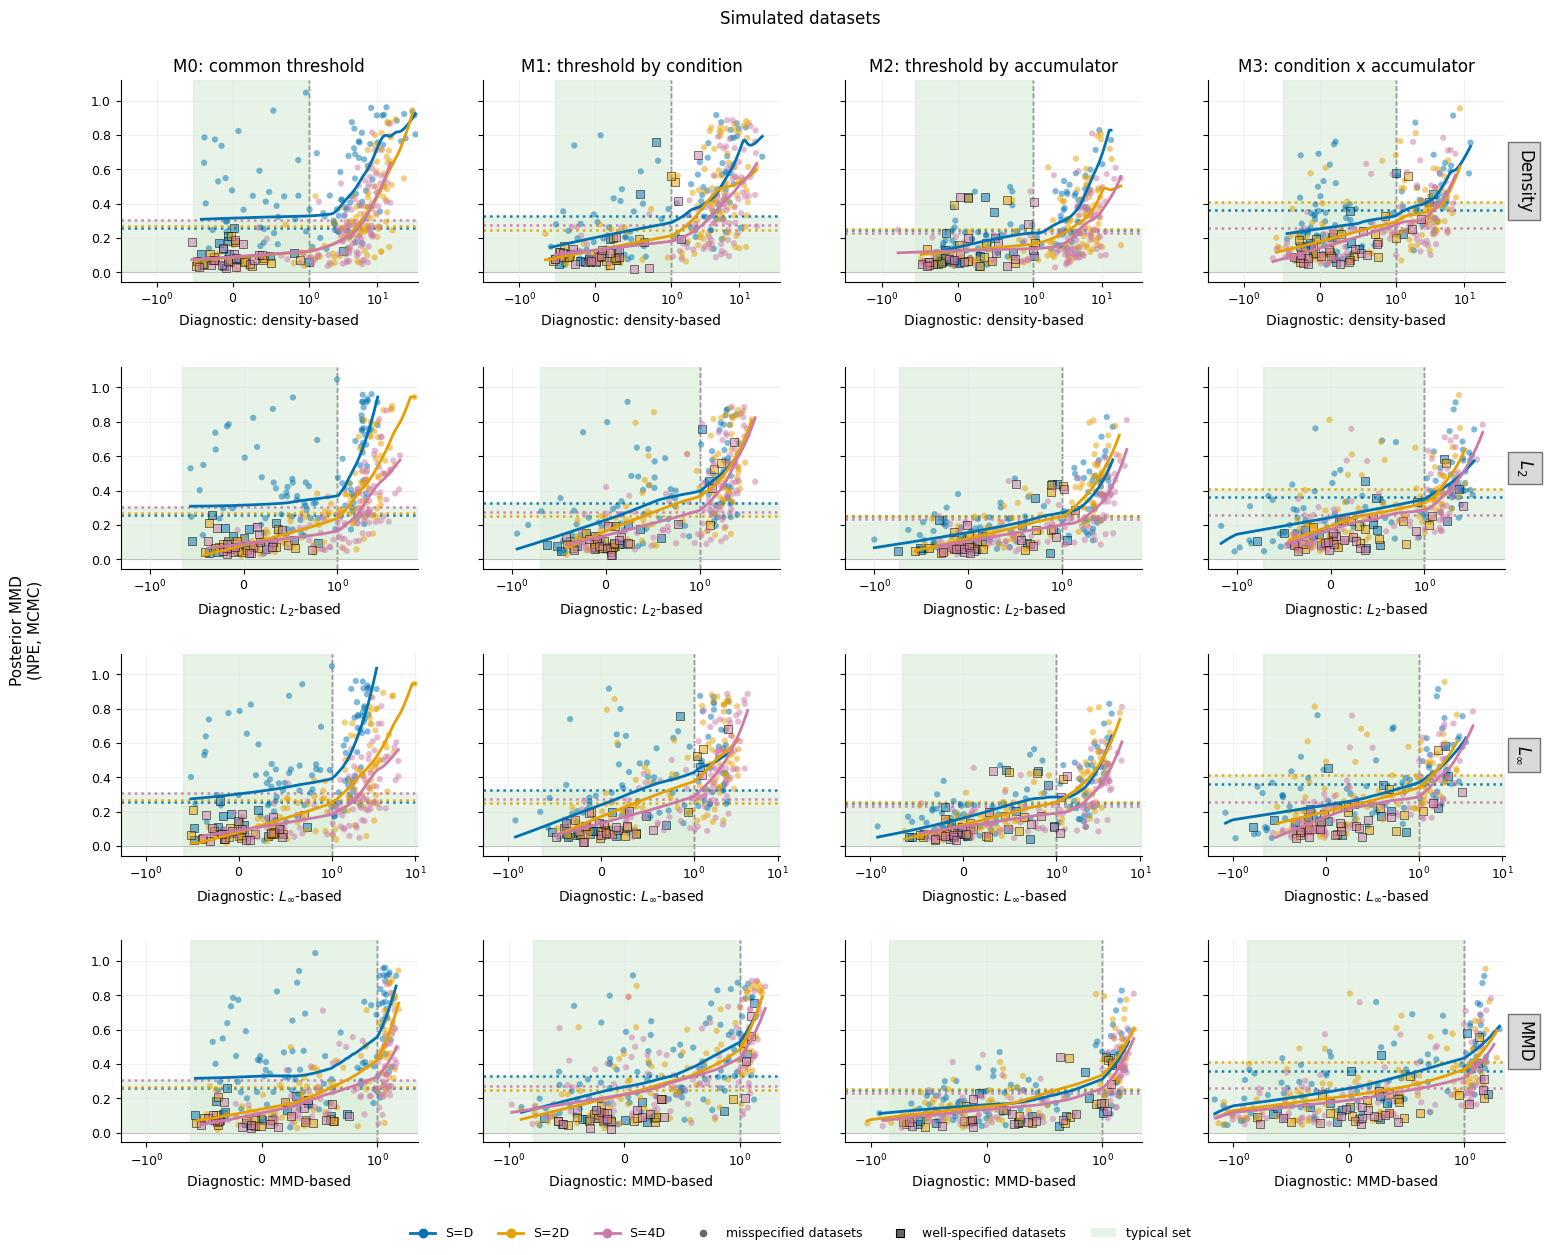

In [6]:
fig_sim_mmd, _ = plot_exact_density_style_grid("posterior_mmd", "simulated")
plt.show()

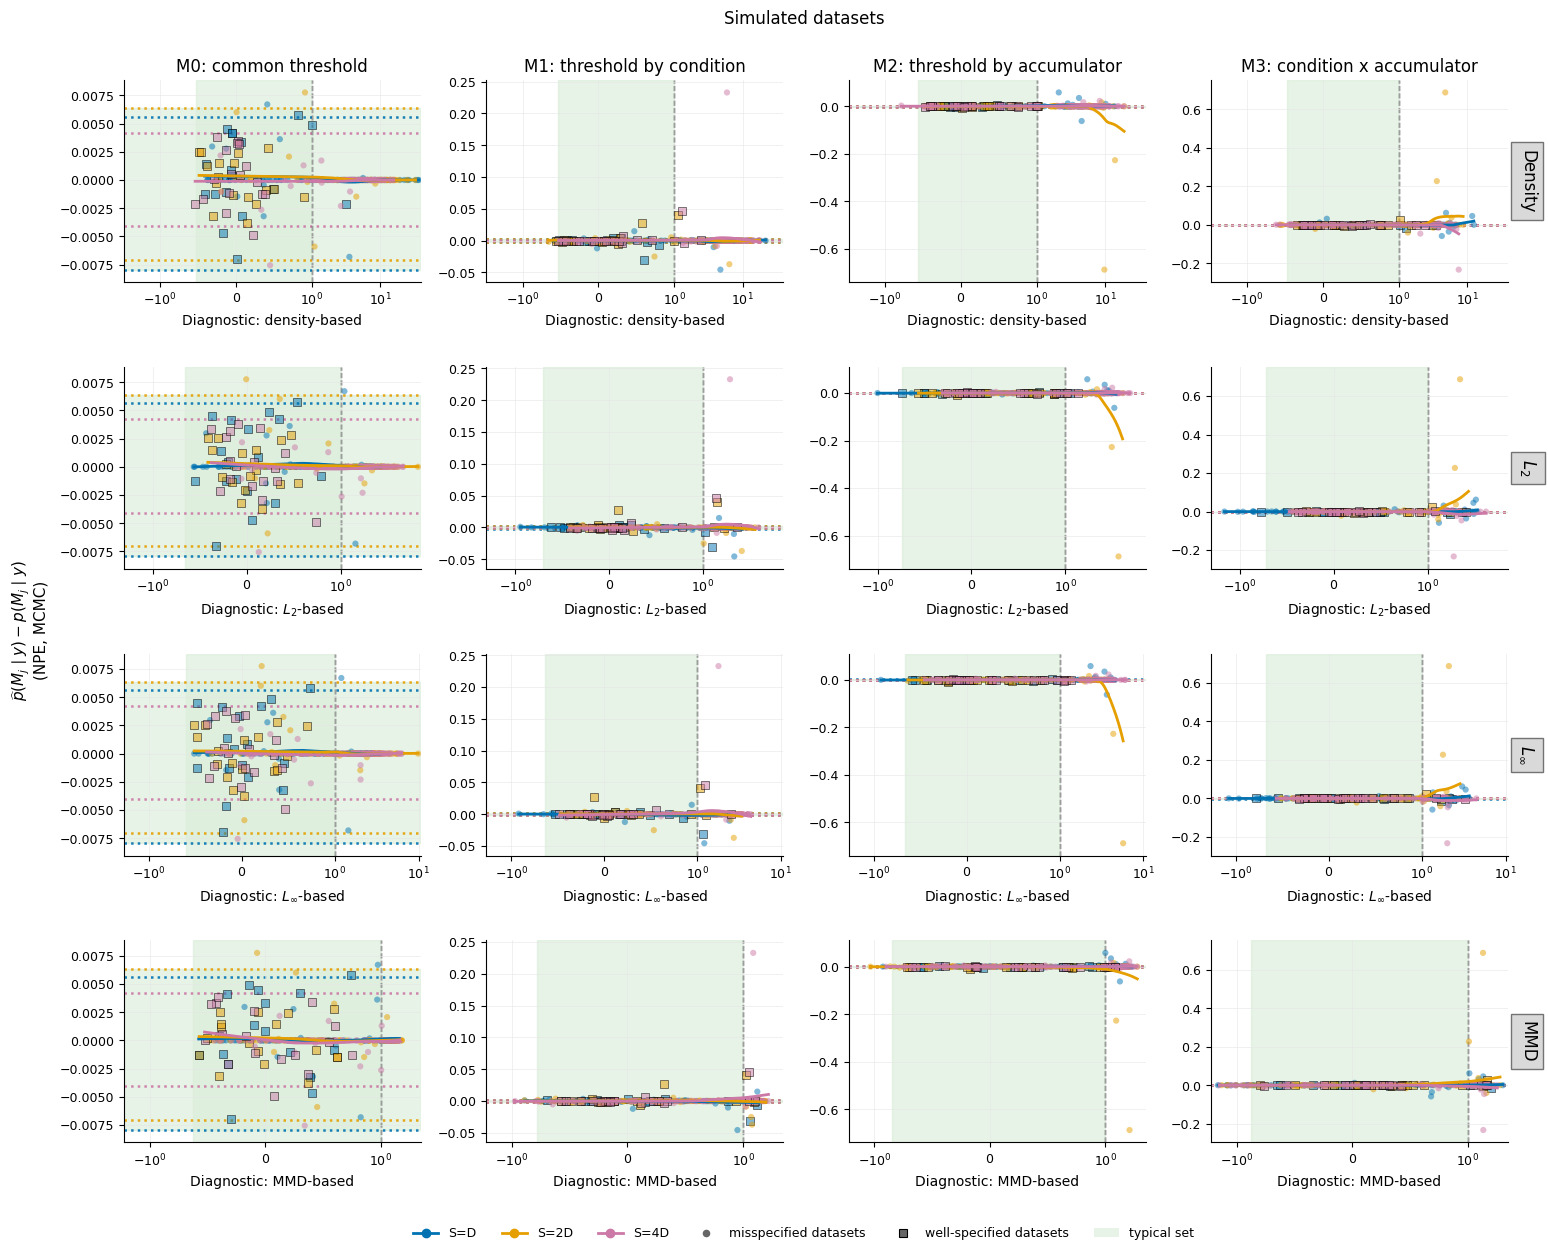

In [7]:
fig_sim_pmp, _ = plot_exact_density_style_grid("pmp", "simulated")
plt.show()

## Empirical datasets

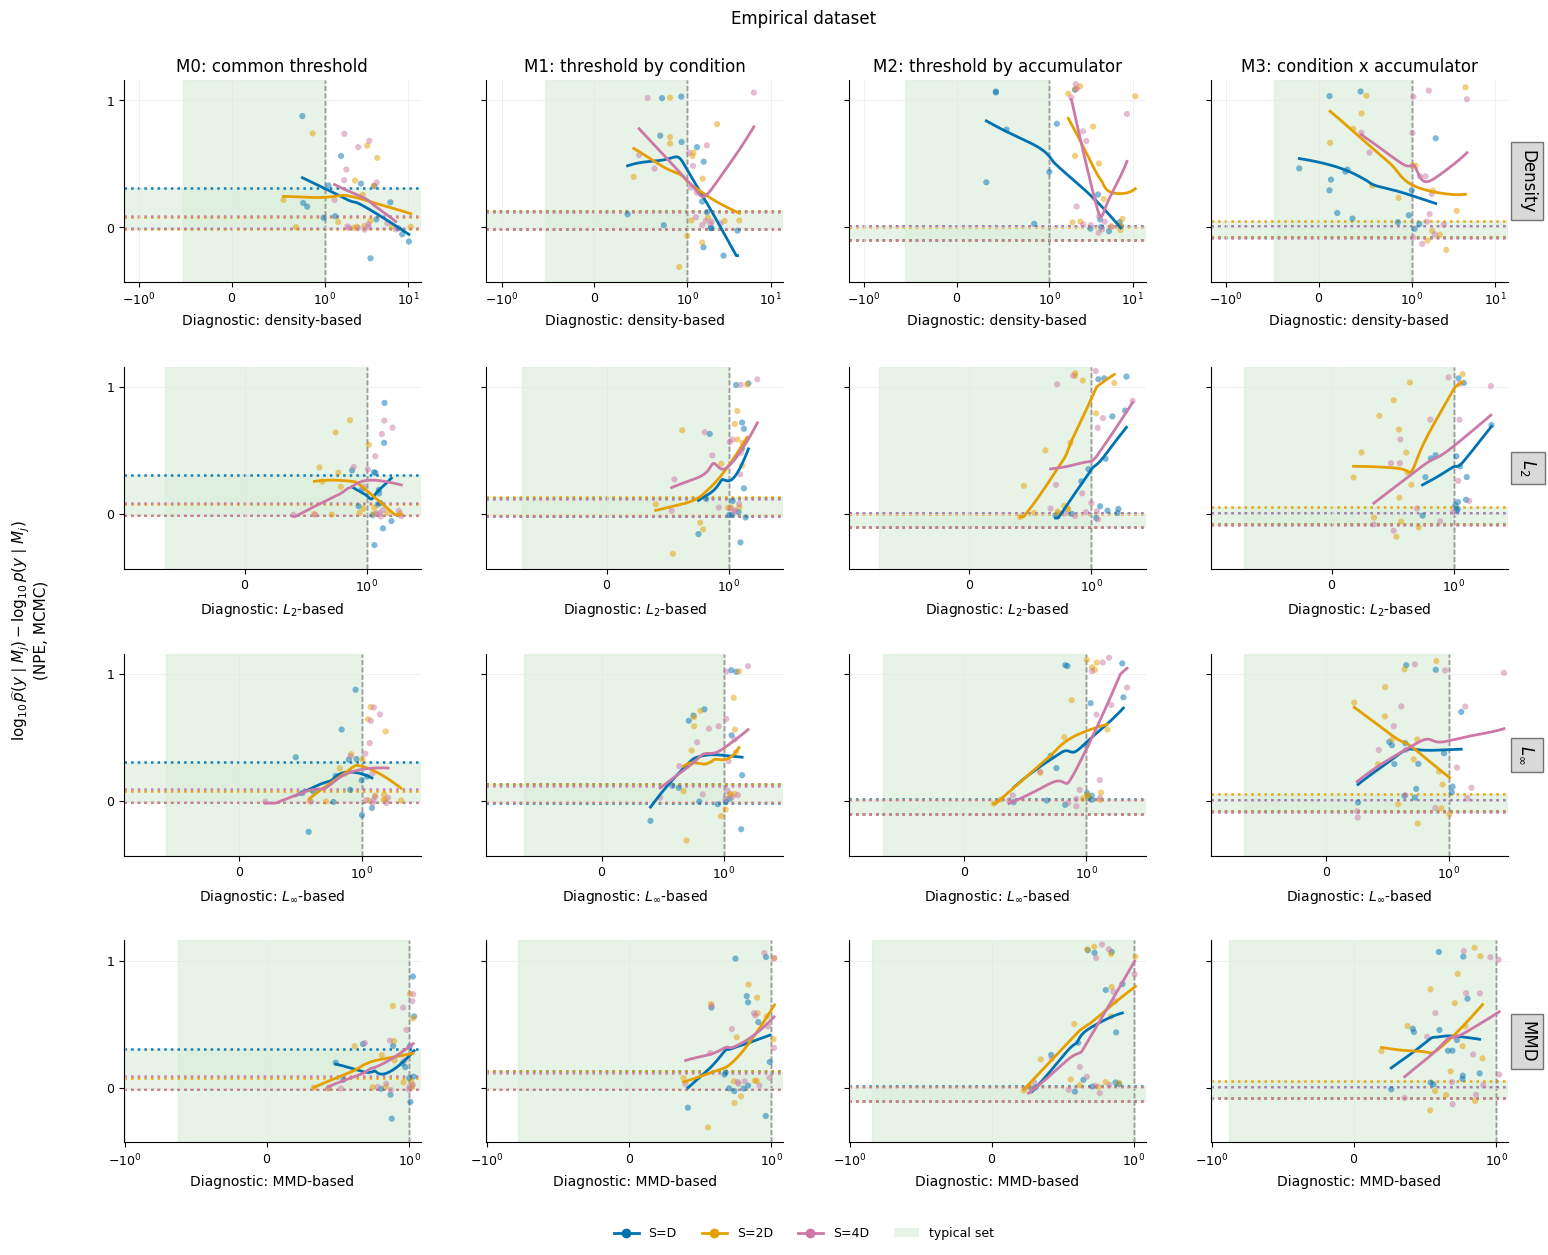

In [8]:
fig_emp_logml, _ = plot_exact_density_style_grid("logml", "empirical")
plt.show()

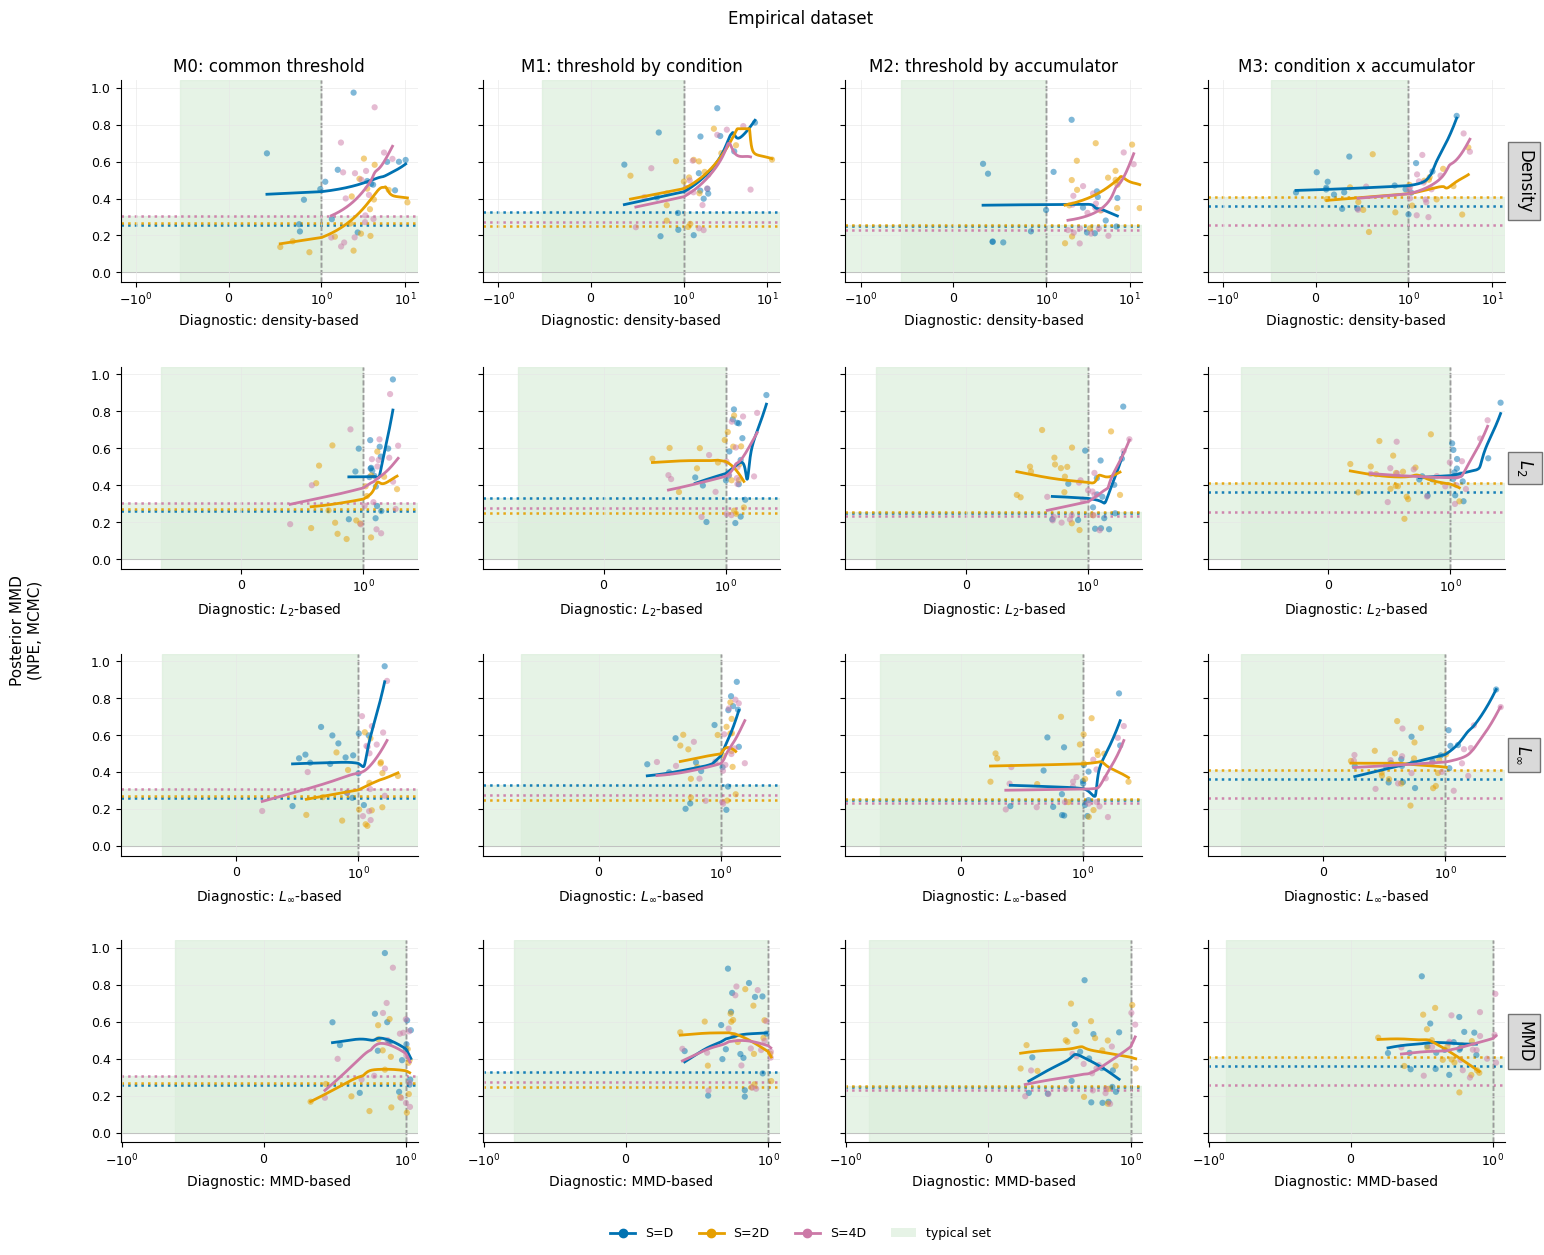

In [9]:
fig_emp_mmd, _ = plot_exact_density_style_grid("posterior_mmd", "empirical")
plt.show()

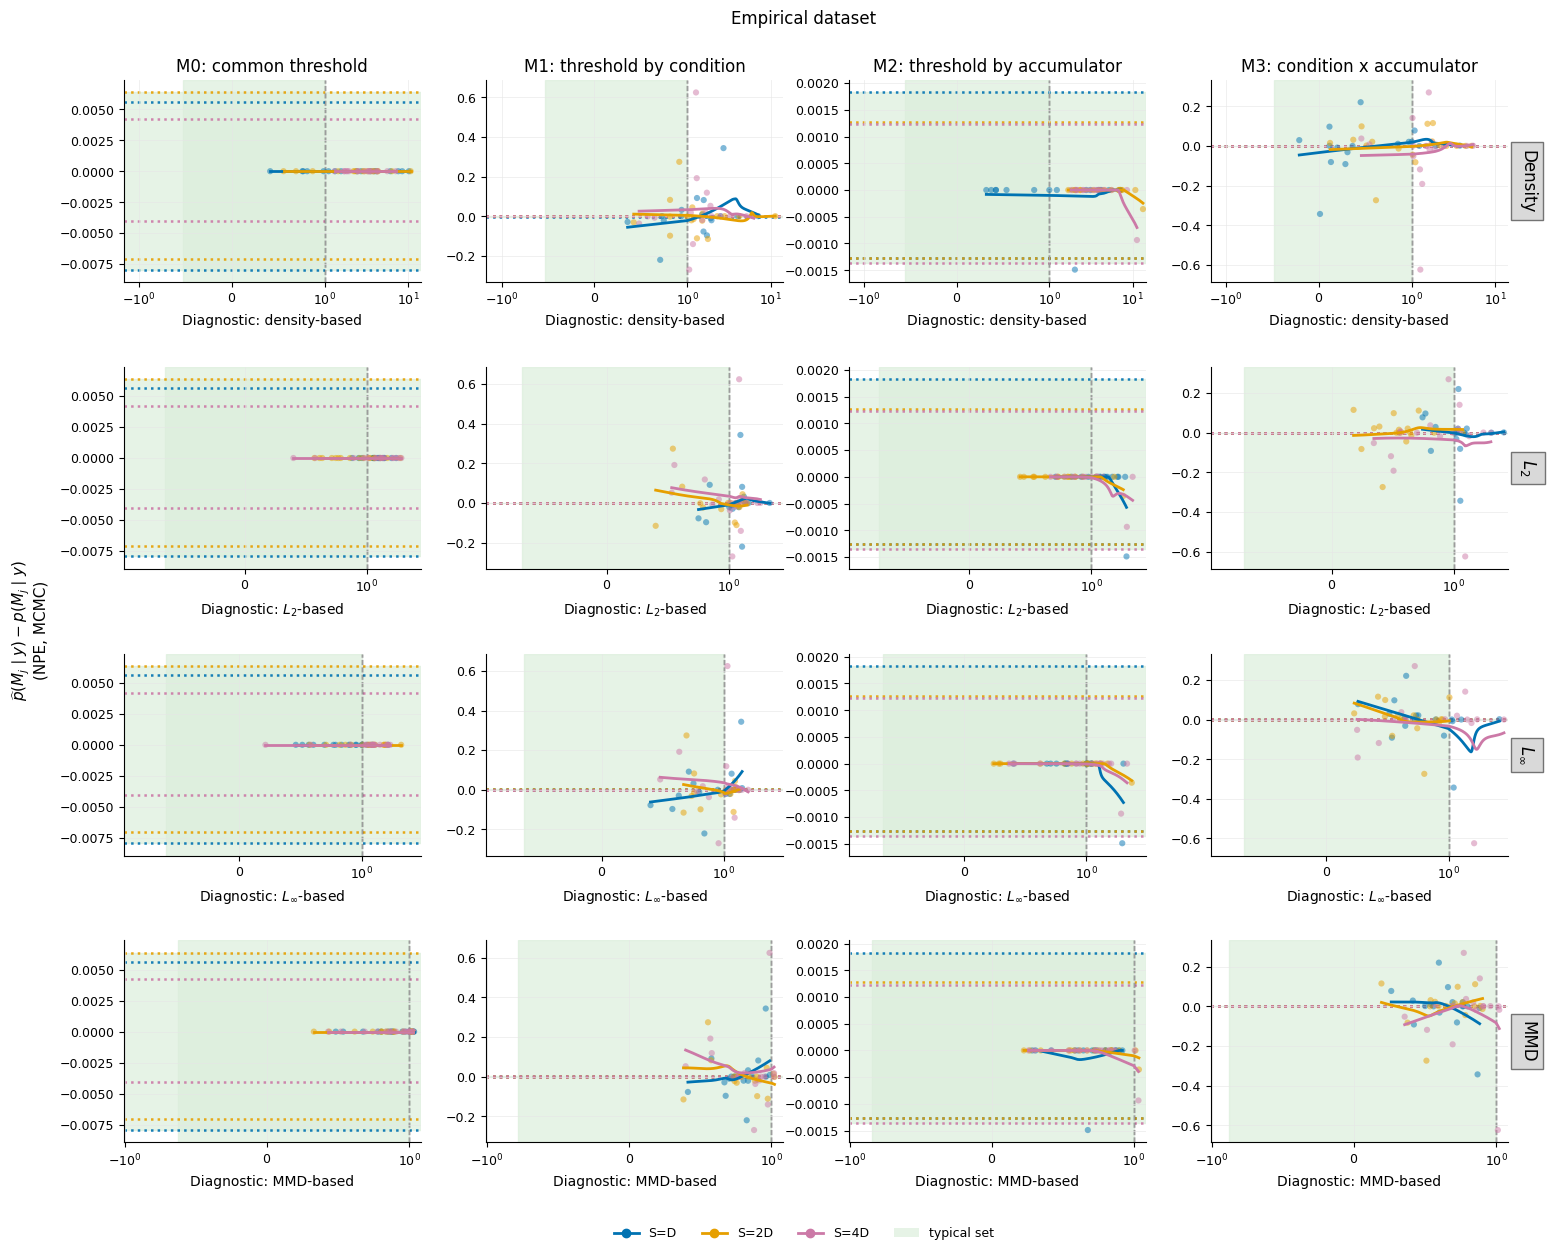

In [10]:
fig_emp_pmp, _ = plot_exact_density_style_grid("pmp", "empirical")
plt.show()